# SETUP or FETCH ENV VARIABLES

In [2]:
import os

# Groq (model provider)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Search API keys
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"] = os.getenv("SERPER_API_KEY")

print("Keys set!")

Keys set!


In [3]:
from langchain.chat_models import init_chat_model

# Use Groq LLM
model = init_chat_model(
    model="groq:llama-3.3-70b-versatile",  # Large model for tool calling
    temperature=0.3   # creative 
)

print("LLM initialized:", model)


LLM initialized: output_version=None profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True} client=<groq.resources.chat.completions.Completions object at 0x00000141C17B12D0> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000141C297A0D0> model_name='llama-3.3-70b-versatile' temperature=0.3 model_kwargs={} groq_api_key=SecretStr('**********') groq_api_base=None groq_proxy=None


In [4]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(
    max_results=5,
    topic="general"
)

print("Tavily search tool ready")

Tavily search tool ready


In [5]:
from langchain_community.utilities import GoogleSerperAPIWrapper

google_search = GoogleSerperAPIWrapper()

print("Google Serper wrapper ready")

Google Serper wrapper ready


C:\Users\AISWARYAPRASAD\AppData\Local\Temp\ipykernel_14524\894811961.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import GoogleSerperAPIWrapper


Google serper search

In [7]:
results= google_search.run("top places to visit Palakakad")
print(results)

Top Attractions in Palakkad · 1. Parambikulam Tiger Reserve · 4.2. (229). Nature & Wildlife Areas · 2. Kalpathy Temple · 4.6. (50). Religious Sites · 3. Best Places to Visit with Family · Silent Valley National Park Palakkad · Malampuzha Gardens and Dam · Palakkad Fort · Vadakkanthara Temple · Kollengode Palace. Palakkad is a blessed land that boasts of lush green paddy fields, mist-drenched mountain ranges, dense forest ranges where rare flora and fauna flourish. Top 10 places to visit in Palakkad, Kerala · 1. Ottapalam · 2. Parambikulam Tiger Reserve · 3. Vadakkanthara Temple · 4. Silent Valley National Park · 5. Palakkad is a blessed land that boasts of lush green paddy fields, mist-drenched mountain ranges, dense forest ranges where rare flora and ... 1. Malambuzha Dam · 2. Tipu Sultan fort · 3. Parambikulam Tiger reserve · 4. Silent Valley National Park · 5. Nelliyampathy · 6. Dhoni Waterfalls · 7. Places of interest · Nelliyampathi – Known as the Ooty of Kerala, about 80 km from 

In [9]:
results_tavily =tavily_search.invoke({"query": "Give me top places to visit in palakakd"})
print(results_tavily)

{'query': 'Give me top places to visit in palakakd', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://irisholidays.com/keralatourism/places-to-visit-in-palakkad', 'title': 'Top 10 Places To Visit In Palakkad, Kerala (UPDATED) – Iris Holidays', 'content': 'Get a FREE Customised Holiday Plan for Kerala 😊. places-to-visit-In-palakkad-kerala. # Top 10 Places to Visit In Palakkad, Kerala (UPDATED). **Silent Valley** National Park, **Ottapalam**, **Dhoni Waterfalls**, **Vadakkanthara Temple**, and **Attapadi** are some of the **best places to visit in Palakkad, Kerala**. Whether you’re looking for a couple’s vacation, seeking an adventurous sojourn with your friends, or browsing Kerala tour packages for a family holiday, you’ll find something for everyone in these brilliant tourist places in Palakkad. From waterfalls to forests, backwaters, hills, and wildlife sanctuaries, there are tons of delightful attractions in Palakkad that you can’t possibly expl

In [10]:

def tavily_search_tool(query: str) -> str:
    """
    Search the web using Tavily for travel info, tips, attractions, etc.
    """
    # Call the existing TavilySearch tool underneath
    return tavily_search.invoke({"query": query})


def google_serper_search_tool(query: str) -> str:
    """
    Search the web using Google Serper for up-to-date travel info.
    """
    return google_search.run(query)

In [11]:
tavily_search_tool("Plan a trip to india")

{'query': 'Plan a trip to india',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.foratravel.com/the-journal/planning-a-trip-to-india',
   'title': "A Beginner's Guide to Planning a Trip to India",
   'content': "Wyoming, Montana, and Colorado claim the most celebrated properties—from sprawling all-inclusive ranches in the Rockies to intimate fly-fishing retreats along blue-ribbon trout streams—but you can find experiences across a broad swath of the West, from the Texas Hill Country to the high desert of New Mexico. # A Beginner's Guide to Planning a Trip to India. India has been on my list for *so* long, so finally getting to check it off felt like a dream come true. From the moment I arrived, I was swept up in the sensory overload — vibrant colors, soul-stirring flavors, the hum of bustling people and a culture so rich it leaves you mesmerized. Here’s your beginner’s guide to India — what to expect, where to go and how to fall in love 

In [12]:

google_serper_search_tool("Plan a 5 trip to india")

"Discover the best of India from as little as $1,334. Choose from a wonderful selection of hotels, flights and rental cars to suit your travel style. You can ... For a comfortable and enjoyable tour, plan your visit between October and March. This period offers the best weather for touring various parts of India. Whether ... We are planning for a 5-6 days trip but kinda not sure on which part of India we should explore. Mostly want to have a quiet time with small treks and good ... and Jaipur)! In this video we share our experiences in India and give tips to plan your dream trip! This video covers where we stayed in ... Thinking of visiting India? Read the Rough Guide to how to plan a trip to India to make the most of your trip. This itinerary can typically be completed in 5-7 days. Delhi and Jaipur are packed with ancient monuments and fascinating markets, stunning ... Hey an ideal itenary would be, · Day 0,Leave Banglore in Night for Munnar · Day 1,Check in at hotel in Munnar,Go for 

In [13]:
from langchain.agents import create_agent

system_prompt = """
You are a travel planner assistant. User asks travel queries like
'plan my trip to X', 'what to do in Y hotel', etc.
Always use the available web search tools (TavilySearch, GoogleSerperSearch)
to look up latest real-world travel info. Provide a helpful and clear itinerary/answers.
"""


Travel planner agent ready!


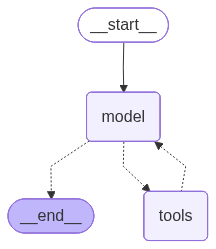

In [14]:
agent = create_agent(
    model=model,
    tools=[tavily_search_tool , google_serper_search_tool],
    system_prompt=system_prompt.strip()  # instructions
)

print("Travel planner agent ready!")
agent

In [21]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "have u heard of panaromic getaway in munnar."}
    ]
})

print("Agent answer:\n")
print(response)

Agent answer:

{'messages': [HumanMessage(content='have u heard of panaromic getaway in munnar.', additional_kwargs={}, response_metadata={}, id='2b14b770-2e85-478e-903b-0edb4b823037'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '3hg9bq6k3', 'function': {'arguments': '{"query":"Panaromic Getaway Munnar"}', 'name': 'tavily_search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 388, 'total_tokens': 412, 'completion_time': 0.051720062, 'completion_tokens_details': None, 'prompt_time': 0.020627748, 'prompt_tokens_details': None, 'queue_time': 0.058994204, 'total_time': 0.07234781}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6524-80eb-73b0-96a5-5fb95413fb72-0', tool_calls=[{'name': 'tavily_search_tool', 'args': {'query': 'Panaromic Getaway Munnar'}, 'id': '

In [22]:
response["messages"]

[HumanMessage(content='have u heard of panaromic getaway in munnar.', additional_kwargs={}, response_metadata={}, id='2b14b770-2e85-478e-903b-0edb4b823037'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '3hg9bq6k3', 'function': {'arguments': '{"query":"Panaromic Getaway Munnar"}', 'name': 'tavily_search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 388, 'total_tokens': 412, 'completion_time': 0.051720062, 'completion_tokens_details': None, 'prompt_time': 0.020627748, 'prompt_tokens_details': None, 'queue_time': 0.058994204, 'total_time': 0.07234781}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6524-80eb-73b0-96a5-5fb95413fb72-0', tool_calls=[{'name': 'tavily_search_tool', 'args': {'query': 'Panaromic Getaway Munnar'}, 'id': '3hg9bq6k3', 'type': 'tool_c

In [ ]:
final_answer = response["messages"][-1].content
print(final_answer)

The Panaromic Getaway in Munnar is a luxurious 5-star hotel that offers stunning views, amazing food, and excellent facilities. It has a heated infinity swimming pool, an indoor sports area, and a spa and wellness center. The hotel is located in Chithirapuram, Munnar, and is situated at around 4000 feet above sea level. It has 55 rooms and offers free high-speed WiFi in the public areas. The hotel is known for its panoramic views, and guests have praised its delicious food, clean rooms, and excellent service. The hotel also has a conference hall, a multi-cuisine restaurant, and a sweet shop. It is a popular destination for families and couples, and is considered one of the best hotels in Munnar.


: 